In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shwetabh123/mall-customers")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mall-customers' dataset.
Path to dataset files: /kaggle/input/mall-customers


First 5 rows of dataset:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Numeric columns used for clustering:
Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

Clustered Data:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31     

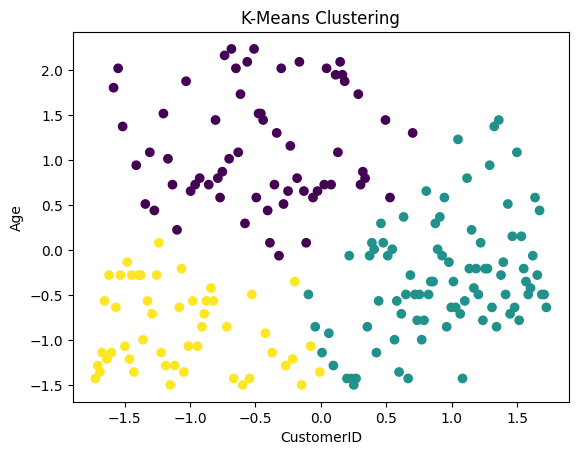

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Step 1: Load CSV file
# -----------------------------
# Replace with your CSV file name
file_path = "Mall_Customers.csv"

df = pd.read_csv(file_path)

print("First 5 rows of dataset:")
print(df.head())

# -----------------------------
# Step 2: Select numeric columns
# -----------------------------
# K-means works only on numerical data
numeric_data = df.select_dtypes(include=['int64', 'float64'])

print("\nNumeric columns used for clustering:")
print(numeric_data.columns)

# -----------------------------
# Step 3: Handle missing values
# -----------------------------
numeric_data = numeric_data.dropna()

# -----------------------------
# Step 4: Standardize data
# -----------------------------
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# -----------------------------
# Step 5: Apply K-Means
# -----------------------------
# Change n_clusters as needed
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to original dataframe
df = df.loc[numeric_data.index]
df['Cluster'] = clusters

print("\nClustered Data:")
print(df.head())

# -----------------------------
# Step 6: Visualize clusters
# -----------------------------
# Works best if dataset has at least 2 numeric columns
if scaled_data.shape[1] >= 2:
    plt.scatter(
        scaled_data[:, 0],
        scaled_data[:, 1],
        c=clusters,
        cmap='viridis'
    )

    plt.xlabel(numeric_data.columns[0])
    plt.ylabel(numeric_data.columns[1])
    plt.title("K-Means Clustering")
    plt.show()
else:
    print("Need at least 2 numeric columns for visualization.")